In [1]:
import torch
import torch.nn.functional as F
from train import train
from cem_model import CEMModelWrapper
from data import get_dataloader

import argparse
import utils
from mapping import map_arg

import os
import json
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter


In [27]:
device='mps'
backbone = map_arg['resnet18'].to(device)
m = CEMModelWrapper(backbone, 10, 32, device=device).to(device)
state = torch.load("runs/sparsemax_maps/state.pth", weights_only=False, map_location='cpu')
m.load_state_dict(state['model_state'])
dset = get_dataloader('cifar10', 1)


In [3]:
data_iter = iter(dset.test_loader)

In [ ]:
image, target = next(data_iter)
m.eval()
with torch.no_grad():
    logits, mask = m(image.to(device), return_maps=True, inference=True, inference_thresh=None)
mask = mask.squeeze(0)
print('True Class', target.item(), "Pred Class", logits.argmax(-1).item())

True Class 8 Pred Class 6


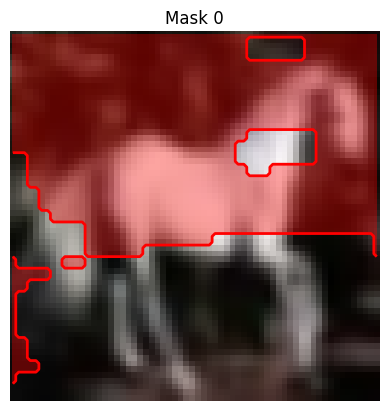

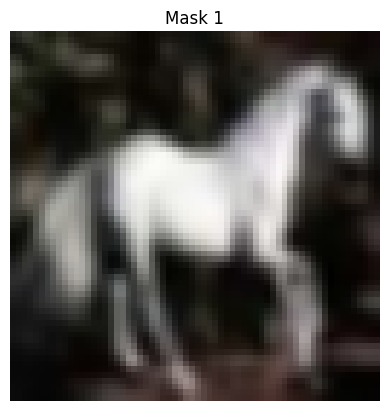

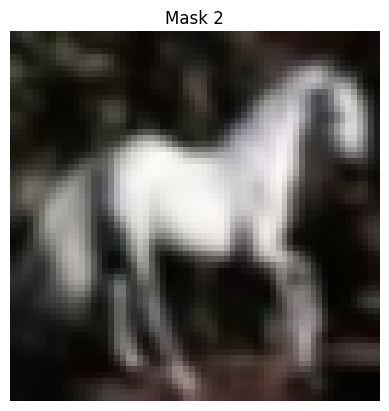

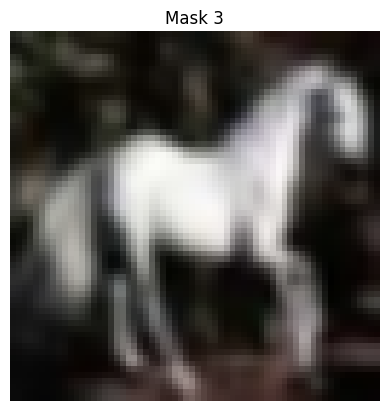

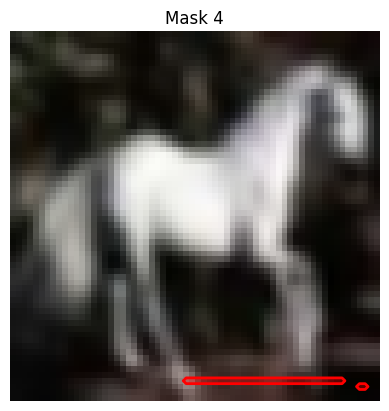

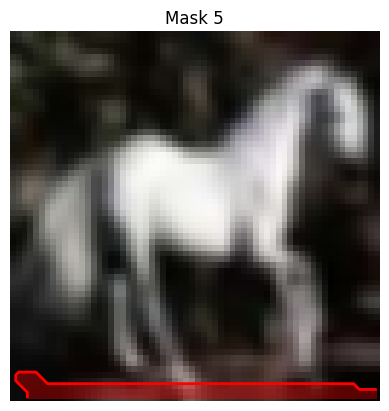

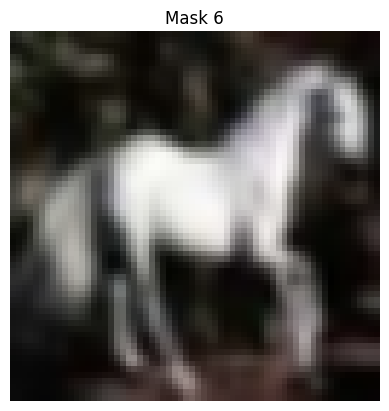

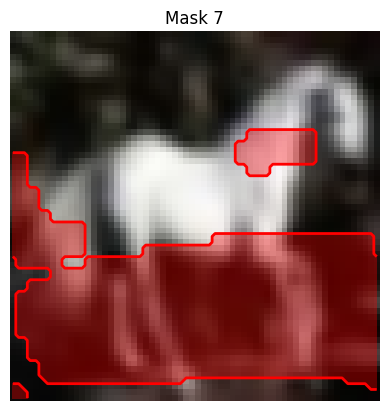

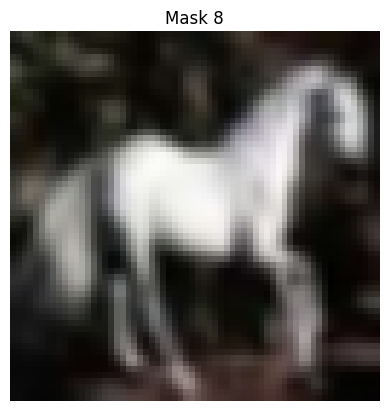

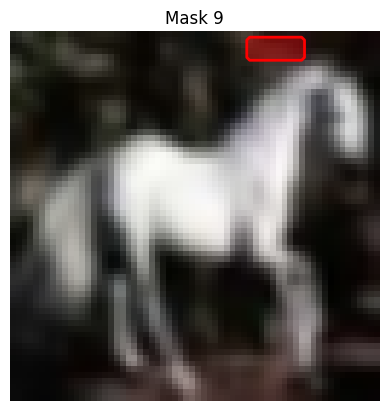

In [24]:
def plot_masks_separately(mask, image, dset, upscale=4):
    if hasattr(image, "detach"):
        image = image.detach()
    if hasattr(mask, "detach"):
        mask = mask.detach()

    image_up = F.interpolate(image.unsqueeze(0), size=64, mode='bilinear', align_corners=False)
    mask_up = F.interpolate(mask.unsqueeze(0), size=64, mode='bilinear', align_corners=False)

    image_up = image_up.squeeze(0).cpu().numpy()
    mask_up = mask_up.squeeze(0).cpu().numpy()

    if image_up.ndim == 3 and image_up.shape[0] in [1, 3]:
        image_up = np.transpose(image_up, (1, 2, 0))

    mean = np.array(dset.mean)
    std = np.array(dset.std)
    image_up = image_up * std + mean
    image_up = np.clip(image_up, 0, 1)

    argmax_map = np.argmax(mask_up, axis=0)

    for i in range(mask_up.shape[0]):
        binary = (argmax_map == i).astype(float)

        plt.figure()
        plt.imshow(image_up)

        if np.any(binary):
            plt.contourf(binary, levels=[0.5, 1], colors=["red"], alpha=0.35)
            plt.contour(binary, levels=[0.5], colors="red", linewidths=2)

        plt.title(f"Mask {i}")
        plt.axis("off")
        plt.show()

plot_masks_separately(mask, image.squeeze(0), dset)

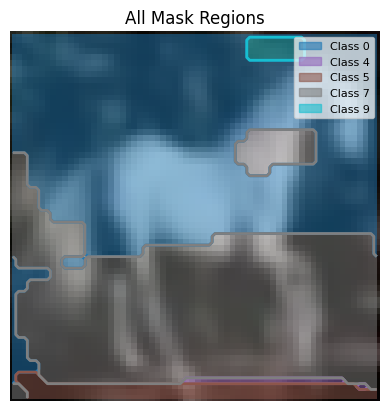

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

def plot_masks_together(mask, image, dset, smooth_sigma=1.0, upscale=4):
    if hasattr(image, "detach"):
        image = image.detach()
    if hasattr(mask, "detach"):
        mask = mask.detach()

    # Upscale image (1CHW) and mask (1CHW) using F.interpolate
    image_up = F.interpolate(image.unsqueeze(0), size=64, mode='bilinear', align_corners=False)
    mask_up = F.interpolate(mask.unsqueeze(0), size=64, mode='bilinear', align_corners=False)

    image_up = image_up.squeeze(0).cpu().numpy()  # CHW
    mask_up = mask_up.squeeze(0).cpu().numpy()    # CHW

    # CHW -> HWC
    if image_up.ndim == 3 and image_up.shape[0] in [1, 3]:
        image_up = np.transpose(image_up, (1, 2, 0))

    # undo normalization
    mean = np.array(dset.mean)
    std = np.array(dset.std)
    image_up = image_up * std + mean
    image_up = np.clip(image_up, 0, 1)

    colors = plt.cm.tab10(np.linspace(0, 1, mask_up.shape[0]))

    argmax_map = np.argmax(mask_up, axis=0)  # HW

    plt.figure()
    plt.imshow(image_up)

    legend_handles = []
    for i in range(mask_up.shape[0]):
        binary = (argmax_map == i).astype(float) 
        # binary[mask_up[i] < 0.5] = 0

        if np.any(binary):
            plt.contourf(binary, levels=[0.5, 1], colors=[colors[i]], alpha=0.5)
            plt.contour(binary, levels=[0.5], colors=[colors[i]], linewidths=2)
            handle = mpatches.Patch(color=colors[i], alpha=0.6, label=f'Class {i}')
            legend_handles.append(handle)

    plt.legend(handles=legend_handles, loc='upper right', fontsize=8, framealpha=0.7)
    plt.title("All Mask Regions")
    plt.axis("off")
    plt.show()



plot_masks_together(mask, image.squeeze(0), dset)